In [1]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(ggh4x))
suppressPackageStartupMessages(library(showtext))
showtext_auto()


In [2]:
#load data
gs_anno = read.table('xxx/PaaSc_Data/Traits/gs_anno.txt',sep = '\t', header=T)
ct_anno = read.table('xxx/PaaSc_Data/Traits/ct_anno.txt',sep = '\t', header=T)
meta = read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_metadata.tsv',sep = '\t', header=T)
label_data = read.table('xxx/PaaSc_Data/TMS/LYMPHOCYTE_COUNT_binarization.tsv',sep='\t')
PaaSc.res=read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_alltraits_PaaSc_score.tsv',sep='\t',header=T)
Fig5C_df=read.table('xxx/PaaSc_Data/TMS/LYMPHOCYTE_COUNT_fishertest.tsv',sep='\t',header=T)
Fig5D_PaaSc_df=read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_alltraits_PaaSc_fishertest.tsv',sep='\t',header=T)
Fig5D_GSDensity_df=read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_alltraits_GSDensity_fishertest.tsv',sep='\t',header=T)
Fig5D_CelliD_df=read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_alltraits_CelliD_fishertest.tsv',sep='\t',header=T)

Fig5A

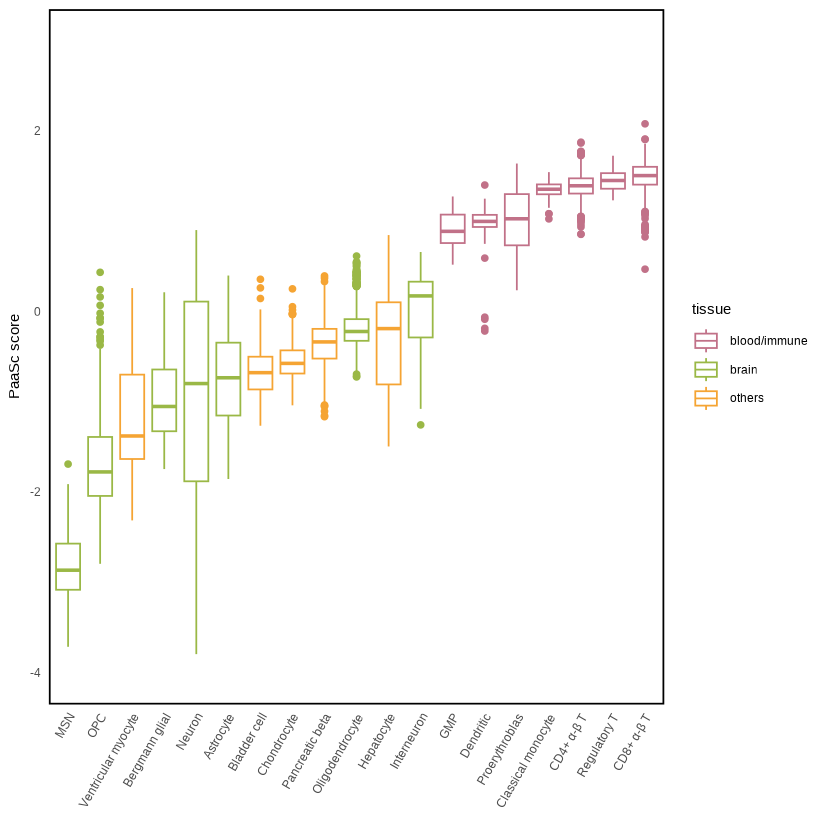

In [3]:
###Fig5A
Fig5A_df = PaaSc.res %>% mutate(celltype=ct_anno$abbreviation[match(meta$cell_ontology_class, ct_anno$CellType)])
Fig5A_df$celltype <- reorder(Fig5A_df$celltype, Fig5A_df[['UKB_460K.blood_LYMPHOCYTE_COUNT']], FUN = median, decreasing = TRUE)
Fig5A_df$tissue <- ct_anno$tissue[match(Fig5A_df$celltype, ct_anno$abbreviation)]

Fig5A <- ggplot(Fig5A_df, aes(x = celltype, y = UKB_460K.blood_LYMPHOCYTE_COUNT,color= tissue)) +
  geom_boxplot() +
  guides(title = NULL)+
  labs(x = NULL, y = 'PaaSc score', title = NULL) +
  scale_color_manual(values = c("blood/immune" = "#C17188", "brain" = "#9AB846", "others" = "#F5A433")) +
  theme_minimal() +
  theme(
    axis.text.x = element_text( angle = 60,hjust = 1, vjust = 1),
    panel.background = element_blank(),
    plot.background = element_blank(),
    panel.border = element_rect( fill = NA, linewidth = 1),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )  +coord_cartesian(ylim = c(-4, 3)) 
Fig5A

Fig5B

Warning message:
“Removed 50 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 50 rows containing non-finite outside the scale range (`stat_density()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_bar()`).”


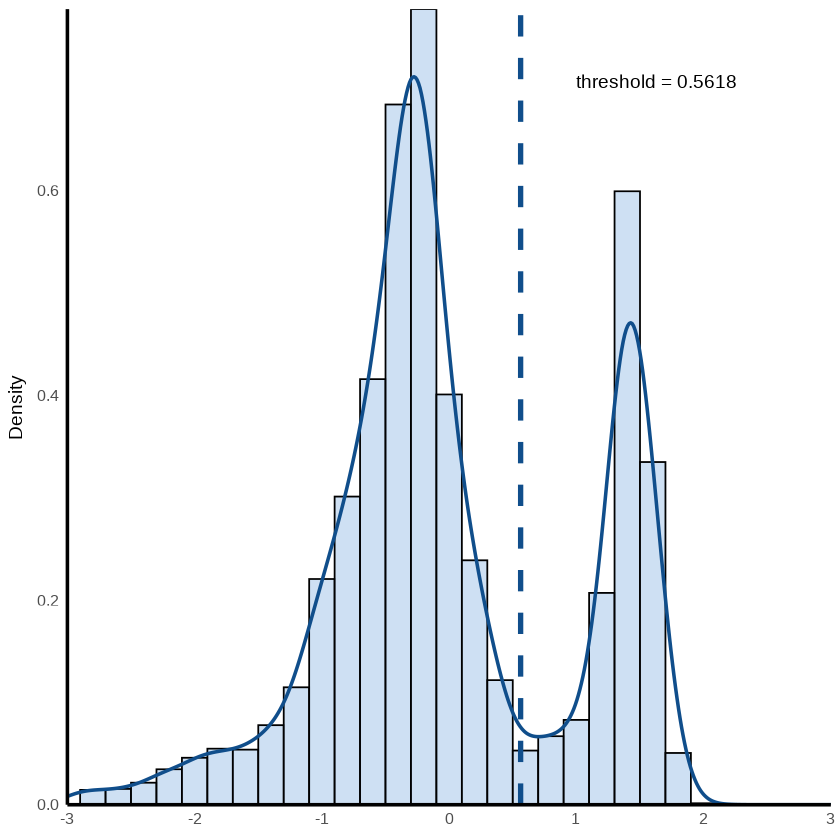

In [4]:
###### Fig5B
t='UKB_460K.blood_LYMPHOCYTE_COUNT'
threshold <- min(PaaSc.res[rownames(label_data[label_data[paste0(t,'.label')] == 'positive', ]), t])

Fig5B<-ggplot(PaaSc.res, aes(x = !!sym(t))) +
  geom_histogram(aes(y = after_stat(density)), 
                 binwidth = 0.2, 
                 fill = "slategray2", 
                 color = "black", 
                 alpha = 0.7, 
                 position = "identity") + 
  geom_density(color = "dodgerblue4", linewidth = 1) + 
  labs(title = NULL, x = NULL, y = "Density") + 
  annotate("text", x = 1, y = 0.7, label = paste0("threshold = ", signif(threshold, 4)), hjust = 0, vjust = 0, color = "black", size = 5) + 
  geom_vline(xintercept = threshold, color = "dodgerblue4", linetype = "dashed", linewidth = 1.5) + 
  theme_minimal() +  
  theme(
    panel.grid = element_blank(),  
    axis.title = element_text(size = 14),  
    axis.text = element_text(size = 12),   
    axis.line = element_line(linewidth = 1)     # 使用 linewidth 代替 size
  ) +
  scale_x_continuous(expand = c(0, 0), limits = c(-3, 3)) + 
  scale_y_continuous(expand = c(0, 0))

Fig5B

#ggsave("Fig5B.pdf", Fig5B, width = 6, height = 6, dpi = 300)

Fig5C

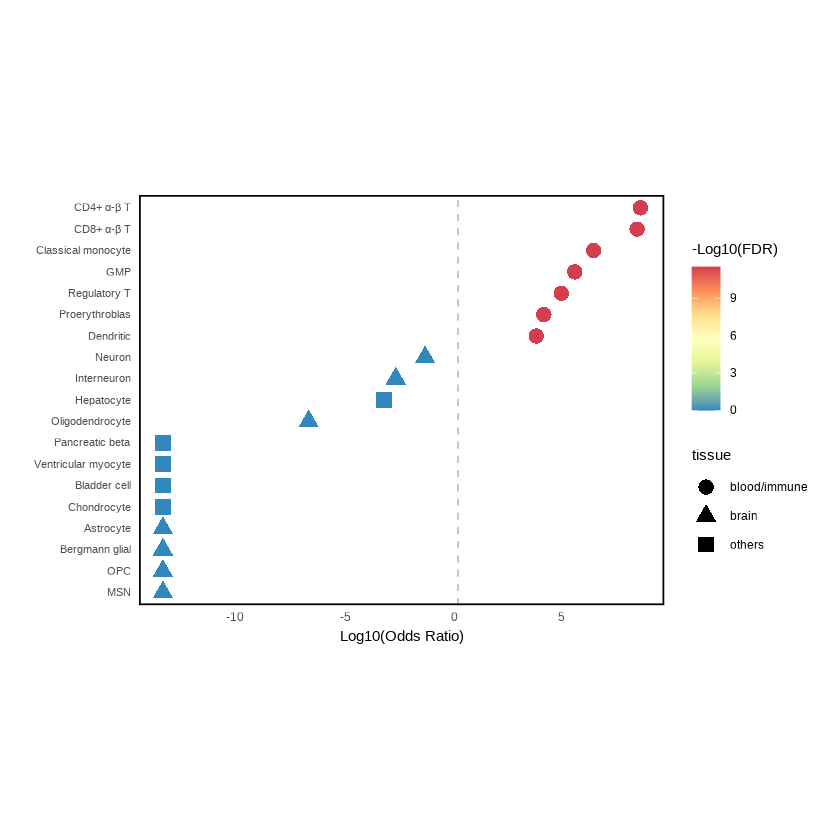

In [6]:
###Fig5C
Fig5C_df$Odds_ratio[Fig5C_df$Odds_ratio == 0] <- 1e-6
Fig5C_df$log_odds_ratio <- log(Fig5C_df$Odds_ratio)
Fig5C_df$padj = p.adjust(Fig5C_df$Pvalue,method = 'fdr')
Fig5C_df$padj[Fig5C_df$padj < 1e-5 ] <- 1e-5
Fig5C_df$logFDR = -log(Fig5C_df$padj)
Fig5C_df$tissue <- ct_anno$tissue[match(Fig5C_df$CellType, ct_anno$abbreviation)]
Fig5C_df$CellType <- factor(Fig5C_df$CellType, levels = Fig5C_df$CellType[order(Fig5C_df$log_odds_ratio)])


Fig5C <- ggplot(Fig5C_df, aes(x=log_odds_ratio, y=CellType))+geom_point( aes(color= logFDR,shape=tissue),fill=NA,size=4)+
  theme_minimal() + 
  theme(
       panel.border = element_rect( fill = NA, linewidth = 1),
    panel.grid = element_blank(),
    axis.text.x = element_text( hjust = 1),
    axis.title.y = element_text(angle = 0, hjust = 1), 
    axis.text.y = element_text(hjust = 1,size = 8)         
  ) +
geom_vline(aes(xintercept = 0),color="gray",linetype="dashed", size = 0.5)+
scale_color_distiller(palette ='Spectral',name ="-Log10(FDR)")+
  xlab("Log10(Odds Ratio)") +                                        
  ylab("") +                                  
  coord_fixed() 
Fig5C
#ggsave("Fig5C.pdf", Fig5C, width = 6, height = 6, dpi = 300)

Fig5D

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“`guide_axis_nested()` was deprecated in ggh4x 0.3.0.
ℹ Please use `legendry::guide_axis_nested()` instead.
ℹ The deprecated feature was likely used in the ggplot2 package.
  Please report the issue at <https:/

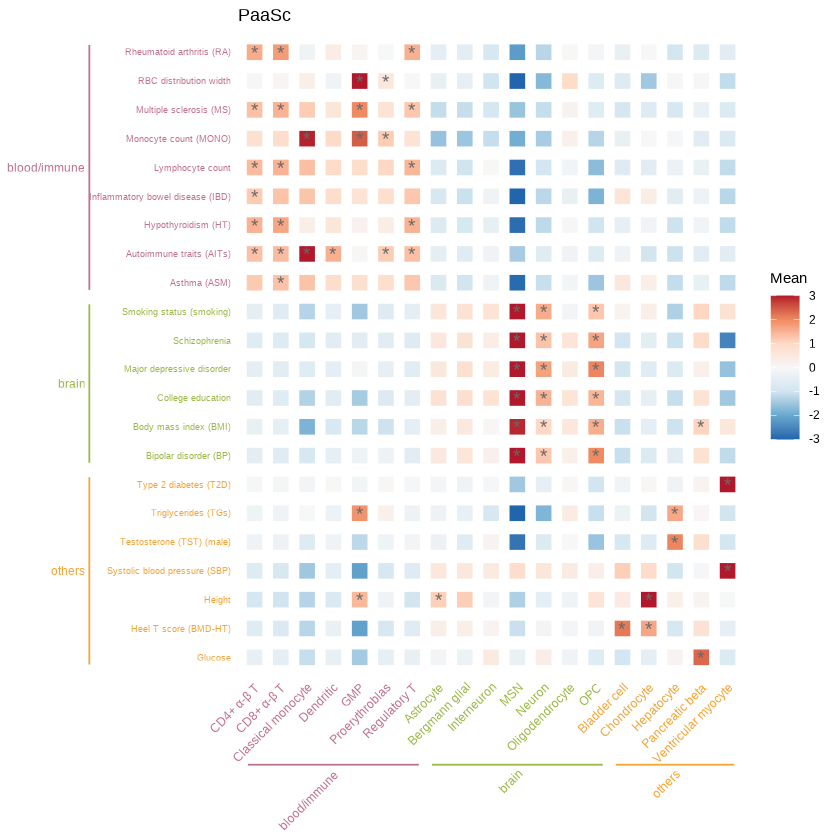

In [7]:
#PaaSc
gs_color=rev(c(rep('#C17188',9),rep('#9AB846',6),rep('#F5A433',7)))
ct_color=c(rep('#C17188',7),rep('#9AB846',7),rep('#F5A433',5))
Fig5D_PaaSc_df$ct_col = factor(ct_anno$tissue[match(Fig5D_PaaSc_df$CellType, ct_anno$abbreviation)],levels=c('blood/immune','brain','others'))
Fig5D_PaaSc_df$gs_col = factor(gs_anno$tissue[match(Fig5D_PaaSc_df$Traits, gs_anno$abbreviation)],levels=c('others','brain','blood/immune'))
Fig5D_PaaSc_df$Mean[Fig5D_PaaSc_df$Mean >3 ] =3
Fig5D_PaaSc_df$Mean[Fig5D_PaaSc_df$Mean < -3 ] = -3
Fig5D_PaaSc = ggplot(Fig5D_PaaSc_df, aes(x = interaction(CellType,ct_col), y = interaction(Traits,gs_col))) +
                        guides(y = "axis_nested",x = "axis_nested")+
                        geom_point(aes(fill=Mean),color='white',shape=22,size=5)+                               
                        scale_fill_distiller(palette ='RdBu')+
                        geom_text(aes(label = ifelse(FDR < 0.05, "*", "")), size = 5, color = "#696969") +
                        labs(title = 'PaaSc',x=NULL,y=NULL)+
                        theme_minimal() + 
                        theme(
                            panel.grid = element_blank(),                  
                            axis.text.x = element_text(angle = 45, hjust = 1, 
                                                   color = ct_color), 
                            axis.title.y = element_text(angle = 0, hjust = 1),
                            axis.text.y = element_text(hjust = 1, size = 7, 
                                                   color = gs_color),
                            ggh4x.axis.nestline.y = element_line(size = 0.5,colour = c("#F5A433","#9AB846","#C17188")), 
                            ggh4x.axis.nesttext.y = element_text(size = 9, colour = c("#F5A433","#9AB846","#C17188")), 
                            ggh4x.axis.nestline.x = element_line(size = 0.5,colour = c("#C17188","#9AB846","#F5A433")), 
                            ggh4x.axis.nesttext.x = element_text(size = 9, colour = c("#C17188","#9AB846","#F5A433"))
                      ) 
Fig5D_PaaSc

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


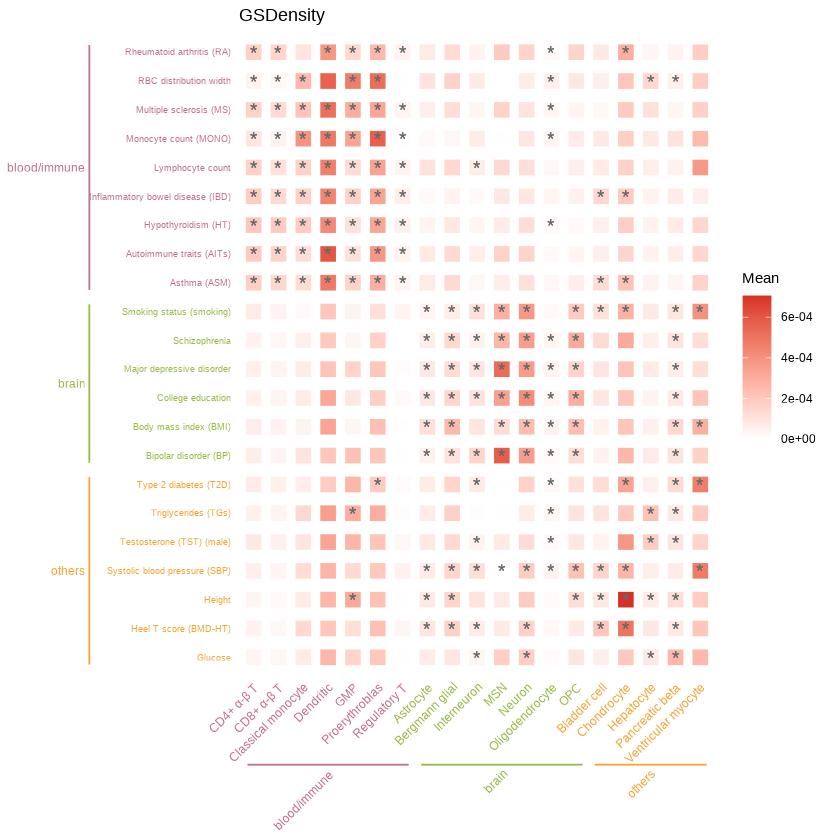

In [8]:
#GSDensity
Fig5D_GSDensity_df$ct_col = factor(ct_anno$tissue[match(Fig5D_GSDensity_df$CellType, ct_anno$abbreviation)],levels=c('blood/immune','brain','others'))
Fig5D_GSDensity_df$gs_col = factor(gs_anno$tissue[match(Fig5D_GSDensity_df$Traits, gs_anno$abbreviation)],levels=c('others','brain','blood/immune'))

Fig5D_GSDensity <- ggplot(Fig5D_GSDensity_df, aes(x = interaction(CellType,ct_col), y = interaction(Traits,gs_col))) +
        guides(x = "axis_nested",y="axis_nested")+
        geom_point(aes(fill=Mean),color='white',shape=22,size=5)+
        geom_text(aes(label = ifelse(FDR < 0.05, "*", "")), size = 5, color = "#696969") +
        scale_fill_gradient(high = "#d73027", low = "white")+
        geom_text(aes(label = ifelse(FDR < 0.05, "*", "")), size = 5, color = "#696969") +
                        labs(title = 'GSDensity',x=NULL,y=NULL)+
                        theme_minimal() + 
                        theme(
                            panel.grid = element_blank(),                  
                            axis.text.x = element_text(angle = 45, hjust = 1, 
                                                   color = ct_color), 
                            axis.title.y = element_text(angle = 0, hjust = 1),
                            axis.text.y = element_text(hjust = 1, size = 7, 
                                                   color = gs_color),
                            ggh4x.axis.nestline.y = element_line(size = 0.5,colour = c("#F5A433","#9AB846","#C17188")), 
                            ggh4x.axis.nesttext.y = element_text(size = 9, colour = c("#F5A433","#9AB846","#C17188")), 
                            ggh4x.axis.nestline.x = element_line(size = 0.5,colour = c("#C17188","#9AB846","#F5A433")), 
                            ggh4x.axis.nesttext.x = element_text(size = 9, colour = c("#C17188","#9AB846","#F5A433"))
                      ) 
Fig5D_GSDensity

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


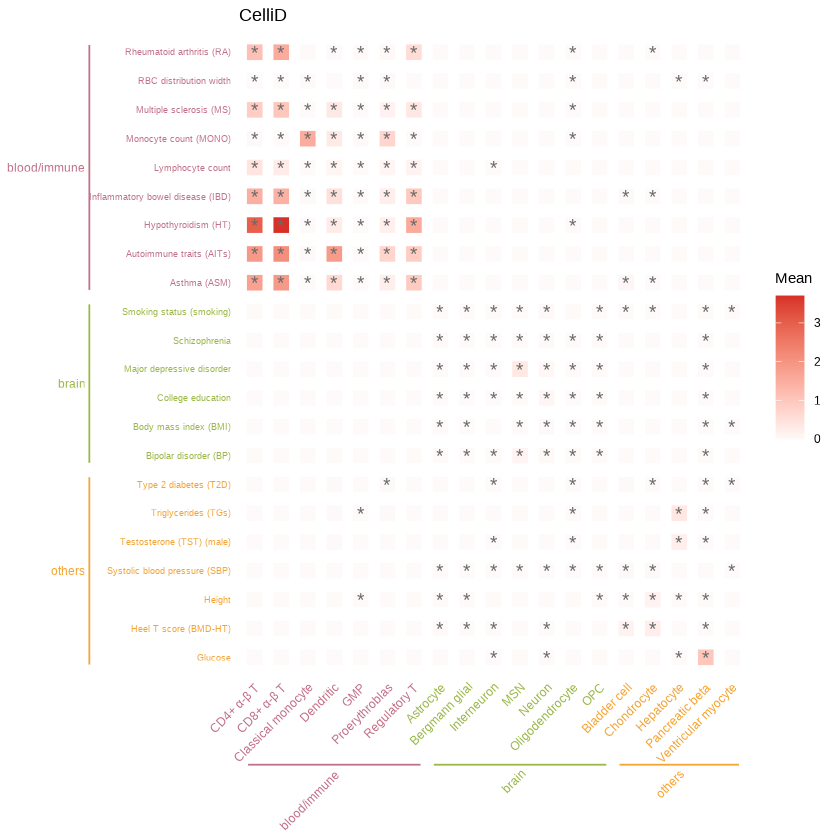

In [9]:
#CelliD
Fig5D_CelliD_df$ct_col = factor(ct_anno$tissue[match(Fig5D_CelliD_df$CellType, ct_anno$abbreviation)],levels=c('blood/immune','brain','others'))
Fig5D_CelliD_df$gs_col = factor(gs_anno$tissue[match(Fig5D_CelliD_df$Traits, gs_anno$abbreviation)],levels=c('others','brain','blood/immune'))

Fig5D_CelliD <- ggplot(Fig5D_CelliD_df, aes(x = interaction(CellType,ct_col), y = interaction(Traits,gs_col))) +
        guides(x = "axis_nested",y= "axis_nested")+
        geom_point(aes(fill=Mean),color='white',shape=22,size=5)+
        scale_fill_gradient(high = "#d73027", low = "#FEFAFA")+
        geom_text(aes(label = ifelse(FDR < 0.05, "*", "")), size = 5, color = "#696969") +
                        labs(title = 'CelliD',x=NULL,y=NULL)+
                        theme_minimal() + 
                        theme(
                            panel.grid = element_blank(),                  
                            axis.text.x = element_text(angle = 45, hjust = 1, 
                                                   color = ct_color), 
                            axis.title.y = element_text(angle = 0, hjust = 1),
                            axis.text.y = element_text(hjust = 1, size = 7, 
                                                   color = gs_color),
                            ggh4x.axis.nestline.y = element_line(size = 0.5,colour = c("#F5A433","#9AB846","#C17188")), 
                            ggh4x.axis.nesttext.y = element_text(size = 9, colour = c("#F5A433","#9AB846","#C17188")), 
                            ggh4x.axis.nestline.x = element_line(size = 0.5,colour = c("#C17188","#9AB846","#F5A433")), 
                            ggh4x.axis.nesttext.x = element_text(size = 9, colour = c("#C17188","#9AB846","#F5A433"))
                      ) 
Fig5D_CelliD